# Corroborated same-band mask-propagation test

Sidecar-only comparison on five light curves. Initial production masks are computed independently per camera. Time intervals supported by at least two distinct cameras are then added to every overlapping same-band camera before rerunning the otherwise unchanged masked-GP baseline. Production source is not modified.

In [1]:
from contextlib import contextmanager
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.backends.backend_pdf import PdfPages

candidate_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next(
    (p for p in candidate_roots if (p / 'pyproject.toml').is_file() and (p / 'malca' / 'core' / 'baseline.py').is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError(f'Could not find the MALCA repository above {Path.cwd()}')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import malca.core.baseline as baseline_module
from malca.config import (
    GP_BRIGHT_SIGMA_THRESH, GP_DIP_SIGMA_THRESH, GP_MIN_GP_POINTS, GP_PAD_DAYS,
    GP_STIFF_MIN_DAYS, GP_STIFF_SCALE_FRACTION,
)
from malca.core.utils import clean_lc
from malca.io.lightcurve_io import load_lightcurve_df, to_asassn_algorithm_frame
from malca.plotting.lightcurve_publication import FIG_SINGLE_COL_WIDTH, PUBLICATION_STYLE, finalize_publication_figure
from malca.stv.events import DEFAULT_BASELINE_KWARGS

JD_OFFSET = 2458000.0
RUN_ROOT = repo_root / 'output' / 'runs' / 'dat3-full-extended_2026-07-01-v4'
TARGETS = [
    ('197569146752', 'dipper - known failure'),
    ('214748665650', 'dipper - illustrative'),
    ('103079592305', 'LTV'),
    ('360777393829', 'LTV'),
    ('489626721133', 'microlensing'),
]
OUTPUT_DIR = repo_root / 'output' / 'pdf' / 'baseline_methods' / 'diagnostics'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = OUTPUT_DIR / 'corroborated_mask_propagation_test.pdf'
PNG_PATH = OUTPUT_DIR / 'corroborated_mask_propagation_197569146752_g.png'
MANIFEST_PATH = OUTPUT_DIR / 'corroborated_mask_propagation_test.csv'


In [2]:
def load_g_band(target_id):
    path = RUN_ROOT / 'bundle_assets' / 'lightcurves' / f'{target_id}.dat3'
    canonical = load_lightcurve_df(path, apply_quality=True)
    cleaned = clean_lc(to_asassn_algorithm_frame(canonical)).reset_index(drop=True)
    bands = pd.to_numeric(cleaned['v_g_band'], errors='coerce')
    lightcurve = cleaned.loc[np.isclose(bands, 0.0)].copy().reset_index(drop=True)
    if lightcurve.empty:
        raise ValueError(f'No g-band data found for {target_id}.')
    return lightcurve

def initial_intervals_by_camera(lightcurve):
    intervals_by_camera = {}
    for camera, sub in lightcurve.groupby('camera#', sort=True):
        ordered = sub.sort_values('JD')
        t = ordered['JD'].to_numpy(float)
        mag = ordered['mag'].to_numpy(float)
        error = ordered['error'].to_numpy(float)
        finite = np.isfinite(t) & np.isfinite(mag)
        median_mag = float(np.nanmedian(mag[finite]))
        base_rough = baseline_module._compute_base_rough(
            t, mag, error, finite, median_mag,
            auto_scale_gp=True,
            min_gp_points=GP_MIN_GP_POINTS,
            stiff_scale_fraction=GP_STIFF_SCALE_FRACTION,
            stiff_min_days=GP_STIFF_MIN_DAYS,
            S0=DEFAULT_BASELINE_KWARGS['S0'],
            q=DEFAULT_BASELINE_KWARGS['q'],
        )
        flags, _, _, _ = baseline_module._mask_excursions(
            t, mag, base_rough, finite, median_mag,
            mag_err=error,
            dip_sigma_thresh=GP_DIP_SIGMA_THRESH,
            bright_sigma_thresh=GP_BRIGHT_SIGMA_THRESH,
            pad_days=GP_PAD_DAYS,
        )
        flagged_indices = np.flatnonzero(flags)
        runs = np.split(flagged_indices, np.flatnonzero(np.diff(flagged_indices) > 1) + 1) if flagged_indices.size else []
        intervals_by_camera[camera] = [
            (float(t[run[0]]) - GP_PAD_DAYS, float(t[run[-1]]) + GP_PAD_DAYS)
            for run in runs if run.size
        ]
    return intervals_by_camera

def corroborated_intervals(intervals_by_camera, min_cameras=2):
    tagged = sorted(
        (float(lo), float(hi), camera)
        for camera, intervals in intervals_by_camera.items()
        for lo, hi in intervals
    )
    if not tagged:
        return []
    components = []
    current_lo, current_hi, current_camera = tagged[0]
    current_cameras = {current_camera}
    for lo, hi, camera in tagged[1:]:
        if lo <= current_hi:
            current_hi = max(current_hi, hi)
            current_cameras.add(camera)
        else:
            if len(current_cameras) >= int(min_cameras):
                components.append((current_lo, current_hi))
            current_lo, current_hi, current_cameras = lo, hi, {camera}
    if len(current_cameras) >= int(min_cameras):
        components.append((current_lo, current_hi))
    return components

original_mask_excursions = baseline_module._mask_excursions

@contextmanager
def propagate_intervals(extra_intervals):
    def mask_with_propagation(*args, **kwargs):
        flags, keep, intervals, s0 = original_mask_excursions(*args, **kwargs)
        t = np.asarray(args[0], float)
        added = np.zeros(len(t), dtype=bool)
        for lo, hi in extra_intervals:
            added |= (t >= float(lo)) & (t <= float(hi))
        flags = np.asarray(flags, bool) | added
        keep = np.asarray(keep, bool) & ~added
        intervals = baseline_module._union_intervals(list(intervals) + list(extra_intervals))
        return flags, keep, intervals, s0
    baseline_module._mask_excursions = mask_with_propagation
    try:
        yield
    finally:
        baseline_module._mask_excursions = original_mask_excursions

def run_comparison(lightcurve):
    current = baseline_module.per_camera_gp_baseline_masked(lightcurve, **DEFAULT_BASELINE_KWARGS).reset_index(drop=True)
    camera_intervals = initial_intervals_by_camera(lightcurve)
    shared_intervals = corroborated_intervals(camera_intervals, min_cameras=2)
    with propagate_intervals(shared_intervals):
        propagated = baseline_module.per_camera_gp_baseline_masked(lightcurve, **DEFAULT_BASELINE_KWARGS).reset_index(drop=True)
    return current, propagated, camera_intervals, shared_intervals


In [3]:
CAMERA_PALETTE = ('#0072B2', '#009E73', '#56B4E9', '#6A3D9A', '#7F7F7F', '#E69F00')

def camera_colors(lightcurve):
    cameras = sorted(lightcurve['camera#'].dropna().unique(), key=str)
    return {camera: CAMERA_PALETTE[i % len(CAMERA_PALETTE)] for i, camera in enumerate(cameras)}

def plot_baseline_panel(ax, frame, colors, title):
    for camera, sub in frame.groupby('camera#', sort=True):
        sub = sub.sort_values('JD')
        x = sub['JD'].to_numpy(float) - JD_OFFSET
        color = colors[camera]
        ax.scatter(x, sub['mag'], s=5, color=color, edgecolors='black', linewidths=0.18, zorder=2)
        ax.plot(x, sub['baseline'], color=color, linewidth=1.1, zorder=3)
        masked = sub['is_masked'].fillna(False).to_numpy(bool)
        if masked.any():
            ax.scatter(x[masked], sub.loc[masked, 'mag'], s=13, marker='x', color='#b2182b', linewidths=0.7, zorder=5)
    ax.invert_yaxis()
    ax.set_ylabel(r'$m_i$ [mag]')
    ax.set_title(title, fontsize=8, pad=3)

def plot_residual_panel(ax, frame, colors, title):
    for camera, sub in frame.groupby('camera#', sort=True):
        sub = sub.sort_values('JD')
        x = sub['JD'].to_numpy(float) - JD_OFFSET
        color = colors[camera]
        ax.scatter(x, sub['resid'], s=5, color=color, edgecolors='black', linewidths=0.18, zorder=2)
        masked = sub['is_masked'].fillna(False).to_numpy(bool)
        if masked.any():
            ax.scatter(x[masked], sub.loc[masked, 'resid'], s=13, marker='x', color='#b2182b', linewidths=0.7, zorder=5)
    ax.axhline(0, color='0.25', linewidth=0.7)
    ax.invert_yaxis()
    ax.set_ylabel(r'$r_i$ [mag]')
    ax.set_title(title, fontsize=8, pad=3)

def make_page(target_id, label, lightcurve, current, propagated):
    colors = camera_colors(lightcurve)
    with plt.rc_context(PUBLICATION_STYLE):
        fig, axes = plt.subplots(4, 1, figsize=(FIG_SINGLE_COL_WIDTH, 8.0), sharex=True)
        plot_baseline_panel(axes[0], current, colors, 'Current independent masks')
        plot_baseline_panel(axes[1], propagated, colors, 'Two-camera corroborated propagation')
        plot_residual_panel(axes[2], current, colors, 'Current residual')
        plot_residual_panel(axes[3], propagated, colors, 'Propagated-mask residual')
        magnitude_limits = axes[0].get_ylim()
        axes[1].set_ylim(magnitude_limits)
        residual_values = np.concatenate([current['resid'].to_numpy(float), propagated['resid'].to_numpy(float)])
        residual_limit = max(0.15, float(np.nanmax(np.abs(residual_values))) * 1.05)
        axes[2].set_ylim(residual_limit, -residual_limit)
        axes[3].set_ylim(residual_limit, -residual_limit)
        axes[-1].set_xlabel('JD - 2458000')
        for ax in axes:
            ax.tick_params(direction='in', top=True, right=True)
        fig.suptitle(f'ASAS-SN {target_id}, g band ({label})', fontsize=8)
        finalize_publication_figure(fig, rect=(0, 0, 1, 0.982))
        return fig


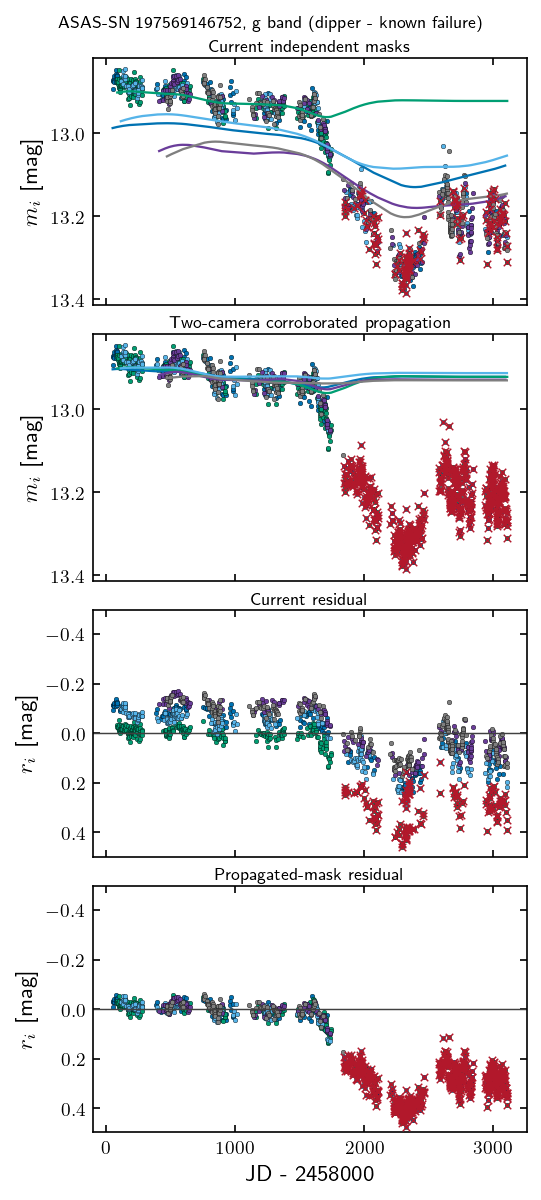

,asas_sn_id,label,points,cameras,initial_masked,propagated_masked,added_masked,corroborated_intervals,corroborated_duration_days,initial_consensus_cameras,propagated_consensus_cameras,initial_sources,propagated_sources
0,197569146752,dipper - known failure,1256,5,136,568,432,1,1269.78643,0,0,masked_gp,masked_gp
1,214748665650,dipper - illustrative,643,6,34,79,45,1,451.04150,2,2,"masked_gp,same_band_consensus","masked_gp,same_band_consensus"
2,103079592305,LTV,1219,5,0,0,0,0,0.00000,4,4,"masked_gp,same_band_consensus","masked_gp,same_band_consensus"
3,360777393829,LTV,1019,5,104,222,118,7,487.12222,0,0,masked_gp,masked_gp
4,489626721133,microlensing,920,5,15,20,5,2,479.80738,4,4,"masked_gp,same_band_consensus","masked_gp,same_band_consensus"


/Users/calder/code/malca/output/pdf/baseline_methods/diagnostics/corroborated_mask_propagation_test.pdf
/Users/calder/code/malca/output/pdf/baseline_methods/diagnostics/corroborated_mask_propagation_197569146752_g.png
/Users/calder/code/malca/output/pdf/baseline_methods/diagnostics/corroborated_mask_propagation_test.csv


In [4]:
manifest_rows = []
with PdfPages(PDF_PATH) as pdf:
    for position, (target_id, label) in enumerate(TARGETS):
        lightcurve = load_g_band(target_id)
        current, propagated, camera_intervals, shared_intervals = run_comparison(lightcurve)
        figure = make_page(target_id, label, lightcurve, current, propagated)
        pdf.savefig(figure)
        if position == 0:
            figure.savefig(PNG_PATH, dpi=300)
            display(figure)
        plt.close(figure)
        current_masked = int(current['is_masked'].sum())
        propagated_masked = int(propagated['is_masked'].sum())
        manifest_rows.append({
            'asas_sn_id': target_id,
            'label': label,
            'points': int(len(lightcurve)),
            'cameras': int(lightcurve['camera#'].nunique()),
            'initial_masked': current_masked,
            'propagated_masked': propagated_masked,
            'added_masked': propagated_masked - current_masked,
            'corroborated_intervals': int(len(shared_intervals)),
            'corroborated_duration_days': float(sum(hi - lo for lo, hi in shared_intervals)),
            'initial_consensus_cameras': int(current.groupby('camera#')['needs_consensus'].any().sum()),
            'propagated_consensus_cameras': int(propagated.groupby('camera#')['needs_consensus'].any().sum()),
            'initial_sources': ','.join(sorted(current['baseline_source'].astype(str).unique())),
            'propagated_sources': ','.join(sorted(propagated['baseline_source'].astype(str).unique())),
        })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(MANIFEST_PATH, index=False)
display(manifest)
print(PDF_PATH)
print(PNG_PATH)
print(MANIFEST_PATH)
